## Step 1 — Load Dataset

In [2]:
import pandas as pd

# isFlaggedFraud column has been removed from this CSV
data = pd.read_csv("paysim_balanced_clean.csv")
print(data.head())
print("Columns:", data.columns.tolist())
print("Shape:", data.shape)

   step      type      amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0   397   CASH_IN    76550.74   C658247527     1096252.93      1172803.66   
1   251   PAYMENT    12617.11  C1812418129      339181.87       326564.76   
2    98  CASH_OUT     8055.06  C1544350298        8055.06            0.00   
3   550  TRANSFER   342309.91   C662184778      342309.91            0.00   
4   586  CASH_OUT  2581549.92   C648614053     2581549.92            0.00   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  
0   C492670573      2208784.02      2132233.28        0  
1  M1924423059            0.00            0.00        0  
2   C912405348            0.00         8055.06        1  
3  C1740503020            0.00            0.00        1  
4   C213455810            0.00      2581549.92        1  
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
Shape: (16426, 10)


## Step 2 — Check Missing Values

In [3]:
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

## Step 3 — Feature Selection

Drop identifier columns and keep only useful features.

In [4]:
data = data.drop(columns=["nameOrig", "nameDest", "step"])
data = data[["amount", "oldbalanceOrg", "newbalanceOrig", "type", "isFraud"]]
print("Shape:", data.shape)
print(data.head())

Shape: (16426, 5)
       amount  oldbalanceOrg  newbalanceOrig      type  isFraud
0    76550.74     1096252.93      1172803.66   CASH_IN        0
1    12617.11      339181.87       326564.76   PAYMENT        0
2     8055.06        8055.06            0.00  CASH_OUT        1
3   342309.91      342309.91            0.00  TRANSFER        1
4  2581549.92     2581549.92            0.00  CASH_OUT        1


## Step 4 — Encode Transaction Type (Categorical → Numerical)

In [5]:
data = pd.get_dummies(data, columns=["type"])
print(data.columns.tolist())

['amount', 'oldbalanceOrg', 'newbalanceOrig', 'isFraud', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


## Step 5 — Separate Features and Target, then Scale

In [6]:
from sklearn.preprocessing import StandardScaler

X = data.drop("isFraud", axis=1)
y = data["isFraud"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features:", X.columns.tolist())

Features: ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


## Step 6 — Train / Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (13140, 8)
Test size:  (3286, 8)


## Step 7 — Train Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("Logistic Regression trained.")

Logistic Regression trained.


## Step 8 — Train Naive Bayes

In [9]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
print("Naive Bayes trained.")

Naive Bayes trained.


## Step 9 — Evaluate Both Models

========================= Logistic Regression =========================
Accuracy : 0.9273
Precision: 0.9395
Recall   : 0.9153
F1 Score : 0.9272
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1622
           1       0.94      0.92      0.93      1664

    accuracy                           0.93      3286
   macro avg       0.93      0.93      0.93      3286
weighted avg       0.93      0.93      0.93      3286



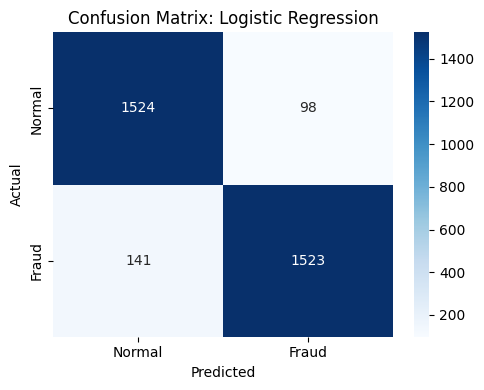

========================= Naive Bayes =========================
Accuracy : 0.6369
Precision: 0.9609
Recall   : 0.2951
F1 Score : 0.4515
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.99      0.73      1622
           1       0.96      0.30      0.45      1664

    accuracy                           0.64      3286
   macro avg       0.77      0.64      0.59      3286
weighted avg       0.77      0.64      0.59      3286



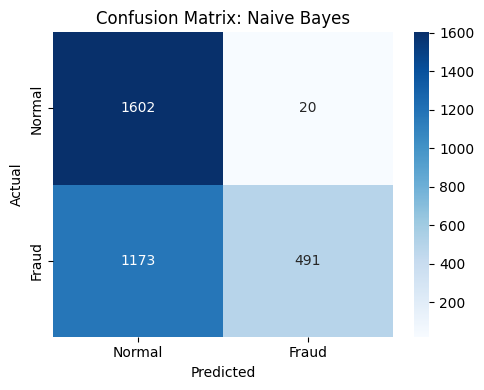

In [11]:
%matplotlib inline
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate(y_true, y_pred, model_name):
    sep = "=" * 25
    print(sep + " " + model_name + " " + sep)
    print("Accuracy : " + str(round(accuracy_score(y_true, y_pred), 4)))
    print("Precision: " + str(round(precision_score(y_true, y_pred), 4)))
    print("Recall   : " + str(round(recall_score(y_true, y_pred), 4)))
    print("F1 Score : " + str(round(f1_score(y_true, y_pred), 4)))
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fraud"],
                yticklabels=["Normal", "Fraud"])
    plt.title("Confusion Matrix: " + model_name)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

evaluate(y_test, lr_pred, "Logistic Regression")
evaluate(y_test, nb_pred, "Naive Bayes")

## Step 10 — Save Models for Flask Deployment

In [12]:
import joblib
import json

joblib.dump(lr_model, "lr_model.pkl")
joblib.dump(nb_model, "nb_model.pkl")
joblib.dump(scaler,   "scaler.pkl")
json.dump(X.columns.tolist(), open("feature_columns.json", "w"))

print("Saved successfully:")
print(" lr_model.pkl")
print(" nb_model.pkl")
print(" scaler.pkl")
print(" feature_columns.json")

Saved successfully:
 lr_model.pkl
 nb_model.pkl
 scaler.pkl
 feature_columns.json


## HYPER PARAMETER TUNING

In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression  

params = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
grid = GridSearchCV(LogisticRegression(class_weight='balanced'), params, cv=5, scoring='f1')
grid.fit(X_train_sc, y_train)
print("Best params:", grid.best_params_)
print("Best F1 score:", grid.best_score_)

NameError: name 'X_train_sc' is not defined